# ENSF 444 - Winter 2026 - Final Project
# Steam Recommendation 

## Erin Kim (30211474) and Abia Jahangir ()

# Preprocessing the Data

In [55]:
import pandas as pd
import numpy as np

df = pd.read_csv("steam_game_reviews.csv", low_memory=False)

df = df.drop_duplicates()

df["review"] = df["review"].fillna("")

df["recommendation"] = df["recommendation"].astype(str).str.strip()

df = df[df["recommendation"].isin(["Recommended", "Not Recommended"])]

df["liked"] = df["recommendation"].map({
    "Recommended": 1,
    "Not Recommended": 0
})

for col in ["hours_played", "helpful", "funny"]:
    df[col] = pd.to_numeric(df[col], errors="coerce")

df["hours_played"] = df["hours_played"].fillna(df["hours_played"].median())
df["helpful"] = df["helpful"].fillna(0)
df["funny"] = df["funny"].fillna(0)

df = df[df["hours_played"] < 1000]

df["hours_played"] = np.log1p(df["hours_played"])

df["review_length"] = df["review"].str.len()

print(df[["recommendation", "liked"]].head())
print(df[["hours_played", "helpful", "funny", "review_length", "liked"]].describe())
print(df["liked"].value_counts())

  recommendation  liked
0    Recommended      1
1    Recommended      1
2    Recommended      1
3    Recommended      1
4    Recommended      1
        hours_played        helpful          funny  review_length  \
count  992152.000000  992152.000000  992152.000000  992152.000000   
mean        3.917261      15.658372       5.060804     386.709627   
std         1.448680      63.708783      35.437444     810.620102   
min         0.000000       0.000000       0.000000       0.000000   
25%         2.990720       1.000000       0.000000      39.000000   
50%         3.945458       2.000000       0.000000     108.000000   
75%         4.921440       5.000000       0.000000     358.000000   
max         6.908655     999.000000     999.000000    8573.000000   

               liked  
count  992152.000000  
mean        0.812155  
std         0.390589  
min         0.000000  
25%         1.000000  
50%         1.000000  
75%         1.000000  
max         1.000000  
liked
1    805781
0    1863

Since the dataset we used had a mix of different data types, 

In [61]:
df_sample = df.sample(n=50000, random_state=42)

X = df_sample[["review", "hours_played", "helpful", "funny", "review_length"]]
y = df_sample["liked"]

In [63]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [65]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, FunctionTransformer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.compose import ColumnTransformer

text_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="constant", fill_value="")),
    ("flatten", FunctionTransformer(lambda x: x.squeeze(), validate=False)),
    ("tfidf", TfidfVectorizer(max_features=1000, stop_words="english"))
])

numeric_features = ["hours_played", "helpful", "funny", "review_length"]

numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

preprocessor = ColumnTransformer([
    ("text", text_transformer, ["review"]),
    ("num", numeric_transformer, numeric_features)
])

In [67]:
from sklearn.linear_model import LogisticRegression

logreg = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000, class_weight="balanced"))
])

In [69]:
from sklearn.ensemble import RandomForestClassifier

rf = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=100,
        random_state=42,
        class_weight="balanced"
    ))
])

In [71]:
from sklearn.neighbors import KNeighborsClassifier

knn = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", KNeighborsClassifier(n_neighbors=5))
])

In [73]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

def evaluate(name, model):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    print(f"\n{name}")
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("Precision:", precision_score(y_test, y_pred))
    print("Recall:", recall_score(y_test, y_pred))
    print("F1-score:", f1_score(y_test, y_pred))

In [77]:
evaluate("Logistic Regression", logreg)
evaluate("Random Forest", rf)
evaluate("KNN", knn)


Logistic Regression
Accuracy: 0.8435
Precision: 0.9547592695074709
Recall: 0.8478928615309006
F1-score: 0.898158391358105

Random Forest
Accuracy: 0.8825
Precision: 0.8887896382313533
Recall: 0.9780071261825777
F1-score: 0.9312664521789997

KNN
Accuracy: 0.826
Precision: 0.8456303338014476
Recall: 0.9617889175574394
F1-score: 0.8999770062083238


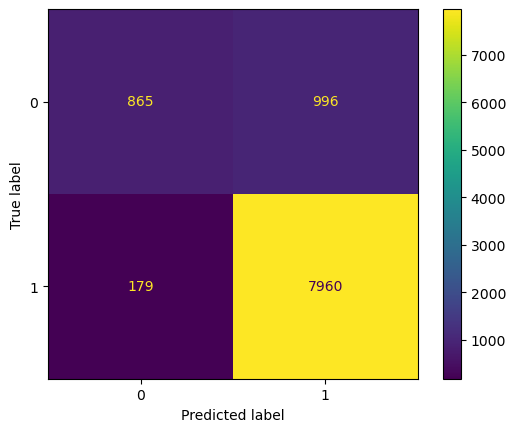

In [80]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(rf, X_test, y_test)

In [82]:
import pandas as pd

results = {
    "Logistic Regression": [0.8435, 0.955, 0.848, 0.898],
    "Random Forest": [0.8825, 0.889, 0.978, 0.931],
    "KNN": [0.826, 0.846, 0.962, 0.900]
}

df_results = pd.DataFrame(results, index=["Accuracy", "Precision", "Recall", "F1-score"])
df_results.T

,Accuracy,Precision,Recall,F1-score
Logistic Regression,0.8435,0.955,0.848,0.898
Random Forest,0.8825,0.889,0.978,0.931
KNN,0.8260,0.846,0.962,0.900
